# Diffract Visualization Showcase

This notebook is a **practical end-to-end example** of `diffract`:

- Build a realistic toy Transformer with `layer_id` / `head_id` metadata
- Run computations via the public `Session` API
- Render multiple plot types via `diffract.viz` (including Hydra-configured plots)
- Apply theming + color control
- **Save every generated figure into `examples/images/` as SVG** (fallback to PNG)

All YAML configs used by this notebook are located in `examples/configs/`.

In [1]:
# !plotly_get_chrome -y

In [2]:
import rootutils
from pathlib import Path
import re
import sys

import plotly.io as pio

root = rootutils.setup_root(".", indicator=".project-root", pythonpath=True)
sys.path.insert(0, str(root / "src"))

# Prefer SVG in notebook outputs.
pio.renderers.default = "svg"

# Example assets live in examples/.
EXAMPLES_DIR = root / "examples"
CONFIGS_DIR = EXAMPLES_DIR / "configs"
IMAGES_DIR = EXAMPLES_DIR / "images"
CONFIGS_DIR.mkdir(parents=True, exist_ok=True)
IMAGES_DIR.mkdir(parents=True, exist_ok=True)


def _safe_stem(name: str) -> str:
    out = []
    for ch in name:
        if ch.isalnum() or ch in ("-", "_", "."):
            out.append(ch)
        else:
            out.append("_")
    return "".join(out).strip("_")


def save_fig(fig, name: str) -> Path:
    """Save figure into examples/images as PNG.

    Note: this repo's assistant tooling can reliably inspect PNG outputs.
    """
    stem = _safe_stem(name)
    png_path = IMAGES_DIR / f"{stem}.png"
    fig.write_image(png_path, scale=2)
    return png_path


def show_and_save(fig, name: str) -> None:
    fig.show()
    out = save_fig(fig, name)
    try:
        rel = out.relative_to(root)
    except Exception:
        rel = out
    print(f"saved: {rel}")


import torch
import torch.nn as nn
from diffract import ParameterOverrides, Session

## 1. Define Neural Network Models

In [3]:
class ToyAttentionHead(nn.Module):
    def __init__(self, d_model: int, d_head: int):
        super().__init__()
        # One projection per head (keeps extraction simple and gives us head_id).
        self.proj = nn.Linear(d_model, d_head, bias=False)

    def forward(self, x):
        return self.proj(x)


class ToyTransformerLayer(nn.Module):
    def __init__(self, d_model: int, n_heads: int, d_head: int, d_ff: int):
        super().__init__()
        self.heads = nn.ModuleList([ToyAttentionHead(d_model, d_head) for _ in range(n_heads)])
        # One FFN per layer (not head-specific).
        self.ffn = nn.Linear(d_model, d_ff, bias=False)

    def forward(self, x):
        # Not used by diffract; kept for completeness.
        heads_out = [h(x) for h in self.heads]
        return self.ffn(x) + sum(heads_out)


class ToyTransformer(nn.Module):
    def __init__(self, d_model: int, n_layers: int, n_heads: int, d_head: int, d_ff: int):
        super().__init__()
        self.layers = nn.ModuleList(
            [ToyTransformerLayer(d_model, n_heads, d_head, d_ff) for _ in range(n_layers)]
        )

    def forward(self, x):
        for layer in self.layers:
            x = layer(x)
        return x


def build_toy_overrides(model: nn.Module) -> dict[str, ParameterOverrides]:
    """Attach layer/head metadata derived from module names."""
    overrides: dict[str, ParameterOverrides] = {}

    for name, module in model.named_modules():
        if not isinstance(module, nn.Linear):
            continue

        m = re.match(r"^layers\.(\d+)\.heads\.(\d+)\.proj$", name)
        if m:
            overrides[name] = ParameterOverrides(
                other_meta={
                    "layer_id": int(m.group(1)),
                    "head_id": int(m.group(2)),
                    "kind": "attn_proj",
                }
            )
            continue

        m = re.match(r"^layers\.(\d+)\.ffn$", name)
        if m:
            overrides[name] = ParameterOverrides(
                other_meta={
                    "layer_id": int(m.group(1)),
                    "head_id": None,
                    "kind": "ffn",
                }
            )

    return overrides


model1 = ToyTransformer(d_model=256, n_layers=2, n_heads=4, d_head=64, d_ff=512)
model2 = ToyTransformer(d_model=512, n_layers=4, n_heads=8, d_head=64, d_ff=1024)

print(f"ToyTransformer small: {sum(p.numel() for p in model1.parameters())} params")
print(f"ToyTransformer big: {sum(p.numel() for p in model2.parameters())} params")

ToyTransformer small: 393216 params
ToyTransformer big: 3145728 params


## 2. Initialize Session and Add Models

In [4]:
session = Session()

with session:
    print(f"Kernels: {len(session.list_kernels())}")
    session.add(
        model1,
        model_id="toy_small",
        parameter_overrides=build_toy_overrides(model1),
    )
    session.add(
        model2,
        model_id="toy_big",
        parameter_overrides=build_toy_overrides(model2),
    )
    print(f"Parameters: {len(session.list_parameters())}")

Kernels: 65
Parameters: 46


## 3. Compute Fields

In [5]:
with session:
    for field in ["shape", "frob_norm", "effective_rank", "stable_rank"]:
        session.compute(field)
        print(f"✓ {field}")

✓ shape
✓ frob_norm
✓ effective_rank
✓ stable_rank


## 3b. Plot: greater_dim boxplot

This uses `diffract.viz` (public `Session` API only) to render a boxplot of `greater_dim` grouped by `model_id`.

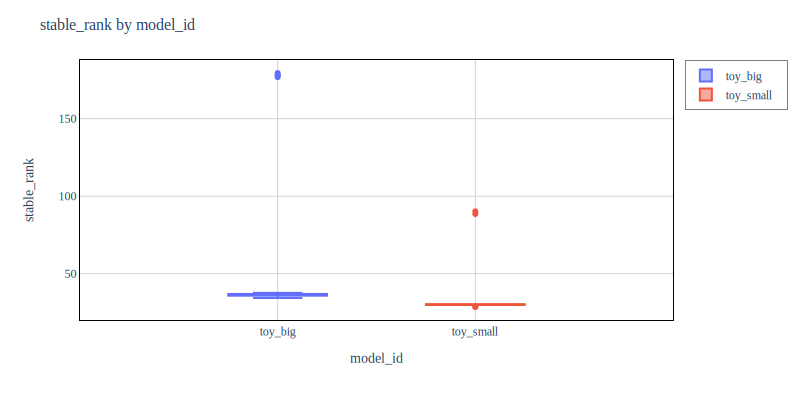

saved: examples/images/3b_stable_rank_boxplot.png


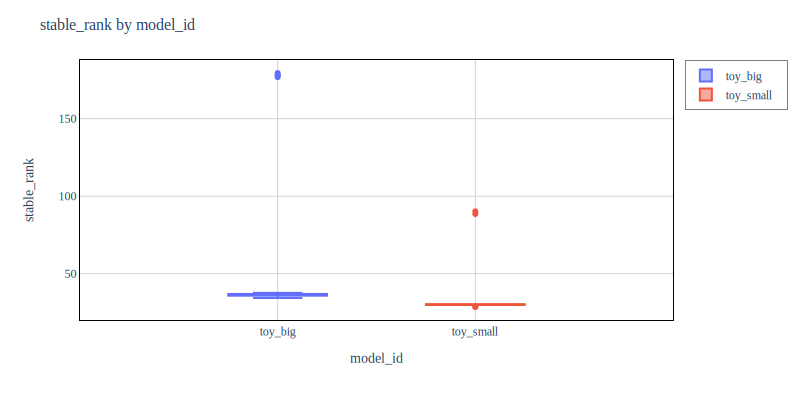

saved: examples/images/3b_stable_rank_boxplot_from_yaml.png


In [6]:
from diffract.viz.plots.scalar import BoxPlot

with session:
    fig = session.draw(
        plot=BoxPlot(
            field="stable_rank",
            title="stable_rank by model_id",
            group_by="model_id",
        )
    )
    show_and_save(fig, "3b_stable_rank_boxplot")

# Same plot rendered from a YAML config (Hydra `_target_`) with optional overrides.
# This is useful for keeping complex plot definitions declarative.
with session:
    fig2 = session.draw(
        config_path=CONFIGS_DIR / "boxplot_stable_rank.yaml",
        overrides=[],
    )
    show_and_save(fig2, "3b_stable_rank_boxplot_from_yaml")

## 3c. Plot: scatter (stable_rank vs frob_norm)

A generic scatter plot based on two scalar fields, grouped by `model_id`.

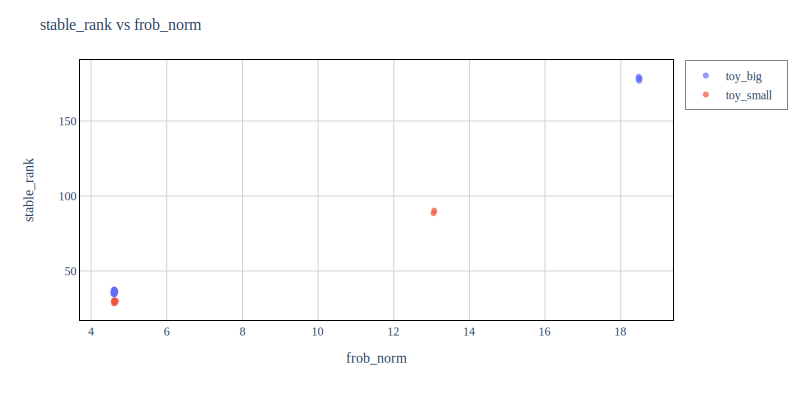

saved: examples/images/3c_scatter_stable_rank_vs_frob_norm.png


In [7]:
from diffract.viz.plots.scatter import ScatterPlot

with session:
    fig = session.draw(
        plot=ScatterPlot(
            x_field="frob_norm",
            y_field="stable_rank",
            title="stable_rank vs frob_norm",
            group_by="model_id",
        )
    )
    show_and_save(fig, "3c_scatter_stable_rank_vs_frob_norm")

## 3d. Plot: heatmap pivot (stable_rank by layer_id × head_id)

A generic heatmap built by pivoting a scalar field using metadata keys.

- `row_by="layer_id"`
- `col_by="head_id"` (parameter name)

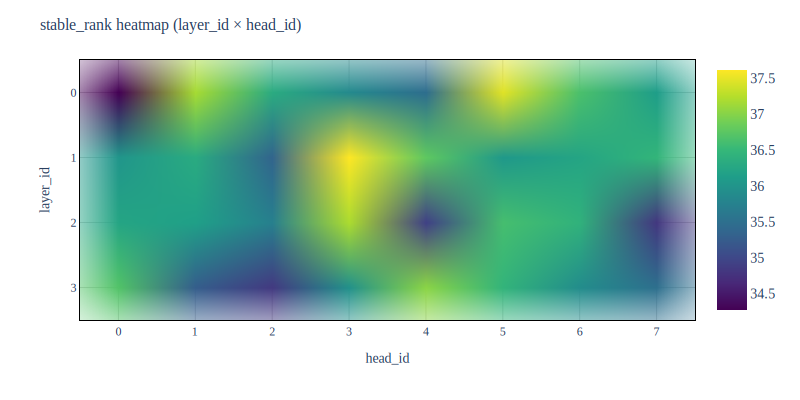

saved: examples/images/3d_heatmap_stable_rank_model_by_param.png


In [8]:
from diffract.viz.plots.heatmap import HeatmapPivotPlot

with session:
    fig = session.draw(
        plot=HeatmapPivotPlot(
            value_field="stable_rank",
            model_ids=["toy_big"],
            row_by="layer_id",
            col_by="head_id",
            title="stable_rank heatmap (layer_id × head_id)",
            show_text=False,
            colorscale="Viridis",
        )
    )
    show_and_save(fig, "3d_heatmap_stable_rank_model_by_param")

## 3e. Plot: line-by-metadata (frob_norm by in_model_idx)

A generic “sparkline-like” plot: scalar metric vs a metadata key (x-axis).

This expects `in_model_idx` to exist in exported metadata (it comes from extractor metadata for this notebook models).

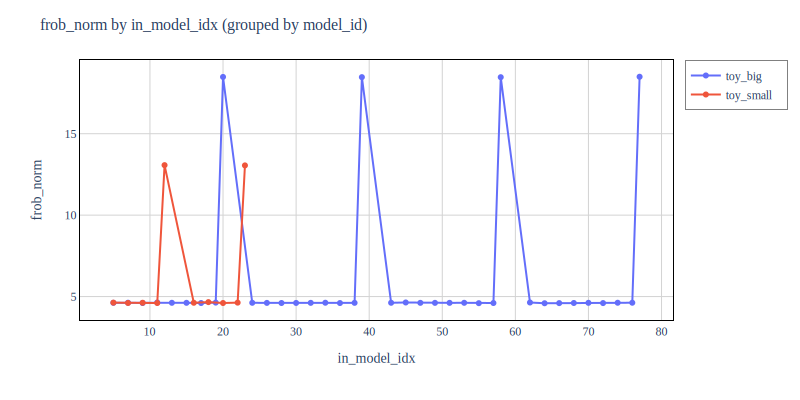

saved: examples/images/3e_line_frob_norm_by_in_model_idx.png


In [9]:
from diffract.viz.plots.lines import LineByMetaPlot

with session:
    fig = session.draw(
        plot=LineByMetaPlot(
            y_field="frob_norm",
            x_by="in_model_idx",
            title="frob_norm by in_model_idx (grouped by model_id)",
            group_by="model_id",
            mode="lines+markers",
        )
    )
    show_and_save(fig, "3e_line_frob_norm_by_in_model_idx")

## 3f. Plot customization: UpdateFigure

`UpdateFigure` lets you keep plots minimal while still having full Plotly customization (layout / traces / axes) in one place.

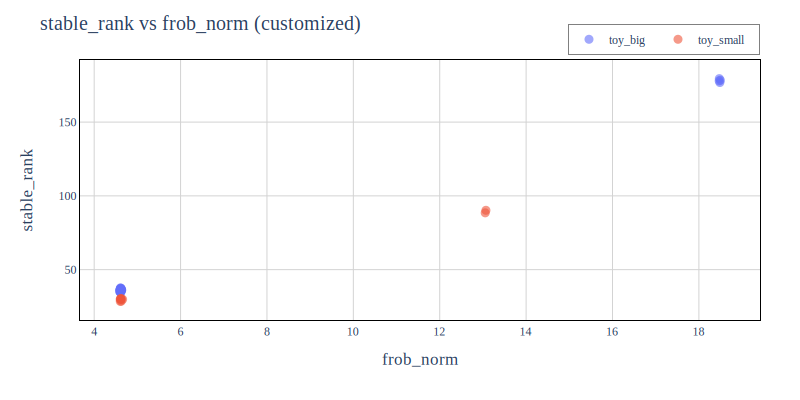

saved: examples/images/3f_updatefigure_scatter_customized.png


In [10]:
from diffract.viz.plots.configurer import UpdateFigure
from diffract.viz.plots.scatter import ScatterPlot

with session:
    fig = session.draw(
        plot=UpdateFigure(
            plot=ScatterPlot(
                x_field="frob_norm",
                y_field="stable_rank",
                title=None,  # set via layout below
                group_by="model_id",
            ),
            layout=dict(
                title="stable_rank vs frob_norm (customized)",
                width=800,
                height=400,
                legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="right", x=1),
            ),
            traces=dict(marker=dict(size=9, opacity=0.6), mode="markers"),
            xaxes=dict(title="frob_norm", showgrid=True, zeroline=False),
            yaxes=dict(title="stable_rank", showgrid=True, zeroline=False),
        )
    )
    show_and_save(fig, "3f_updatefigure_scatter_customized")

## 3g. Plot: violins (weights_svals) + jitter colored by field

A universal violin plot with a configurable jitter overlay.

Here we color jitter points by `jitter_color_field` (same field for demo, but it can be any compatible field).

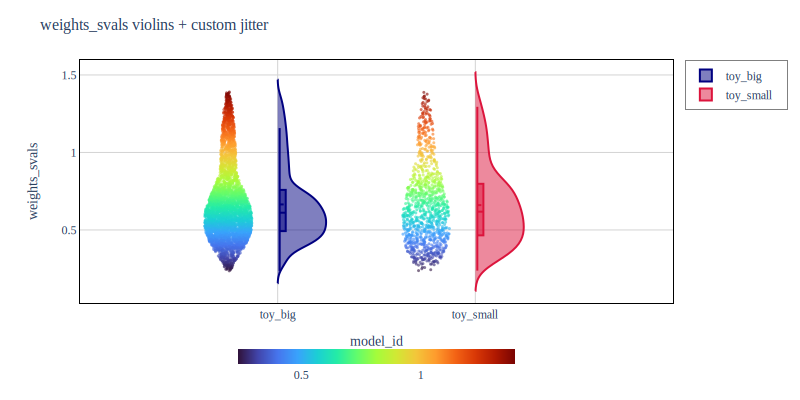

saved: examples/images/3g_violin_weights_svals_jitter.png


In [11]:
with session:
    # weights_svals is required by the violin example
    session.compute("weights_svals")

with session:
    fig = session.draw(
        config_path=CONFIGS_DIR / "violin_weights_svals_jitter.yaml",
        overrides=[],
    )
    show_and_save(fig, "3g_violin_weights_svals_jitter")

## 3h. Plot: boxplot + jitter

A box plot of a scalar field with a configurable jitter overlay, colored by `jitter_color_field`.

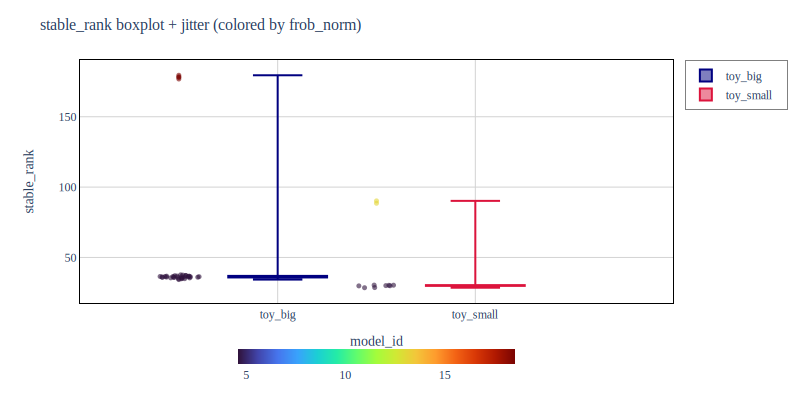

saved: examples/images/3h_boxplot_stable_rank_jitter.png


In [12]:
with session:
    # stable_rank and frob_norm are required by this example
    session.compute("stable_rank", "frob_norm")

with session:
    fig = session.draw(
        config_path=CONFIGS_DIR / "boxplot_stable_rank_jitter.yaml",
        overrides=[],
    )
    show_and_save(fig, "3h_boxplot_stable_rank_jitter")

## 3i. Plot: cluster bar chart (weights_svals)

A generic port of the scary `cluster_box_plot` idea: we bin an array-like field (here `weights_svals`) and draw clustered lines across groups.

- Each trace is an aggregated curve for one group (mean count per bin).
- If `draw_statistics=true`, std is shown below zero (like the original).

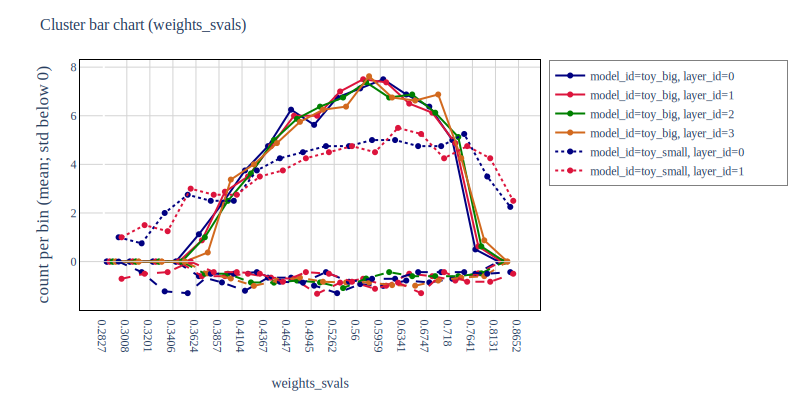

saved: examples/images/3i_cluster_bar_chart_weights_svals.png


In [13]:
with session:
    # weights_svals is required by the cluster bar chart example
    session.compute("weights_svals")

with session:
    fig = session.draw(
        config_path=CONFIGS_DIR / "cluster_bar_chart_weights_svals.yaml",
        overrides=[],
    )
    show_and_save(fig, "3i_cluster_bar_chart_weights_svals")

## 3j. Subplots

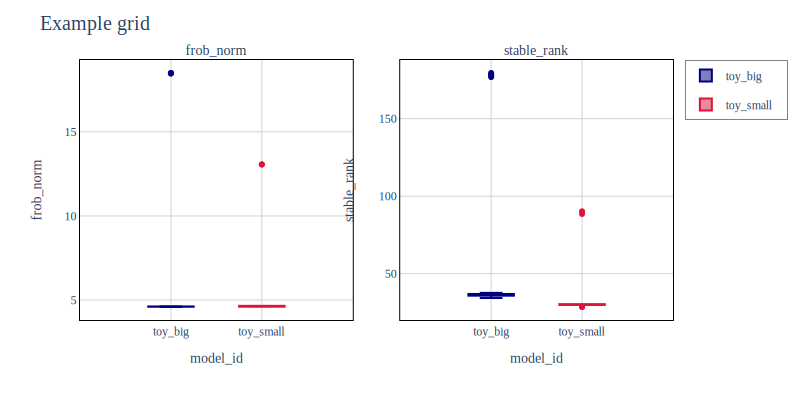

saved: examples/images/3j_grid_example.png


In [14]:
with session:
    fig = session.draw(
        config_path=CONFIGS_DIR / "grid_example.yaml",
        overrides=[],
    )
    show_and_save(fig, "3j_grid_example")

## 3k. Theming and Color Customization

Plots support a unified theming system for publication-ready figures.
- Use `theme=PUBLICATION_THEME` for ICLR-style defaults
- Use `color_by="layer_id"` to color by any metadata key
- Load themes from YAML with `theme_path=...`

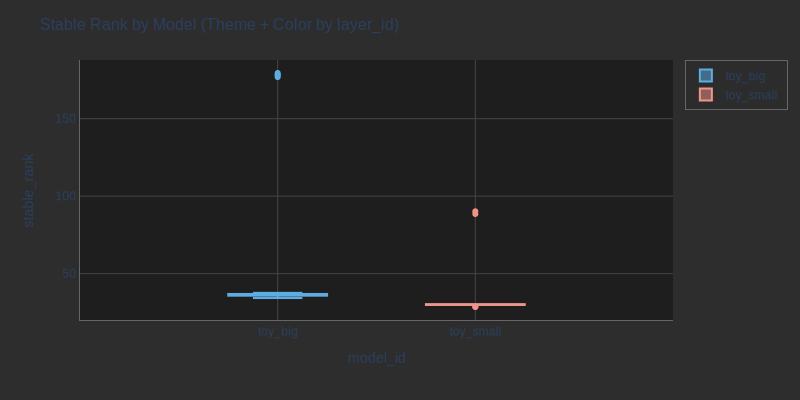

saved: examples/images/3k_theme_color_by_layer.png


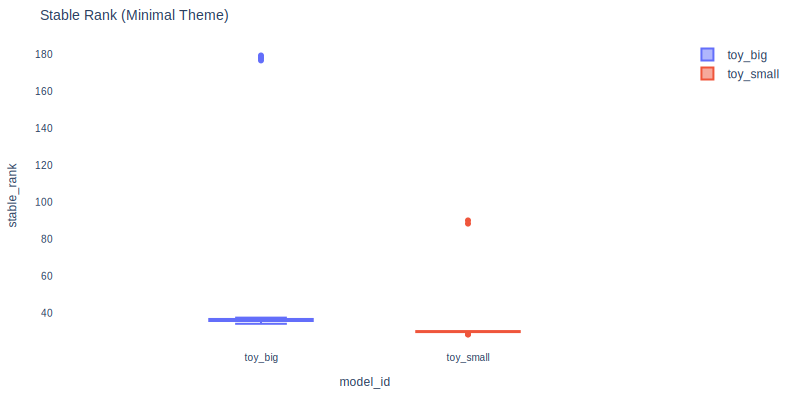

saved: examples/images/3k_theme_minimal.png


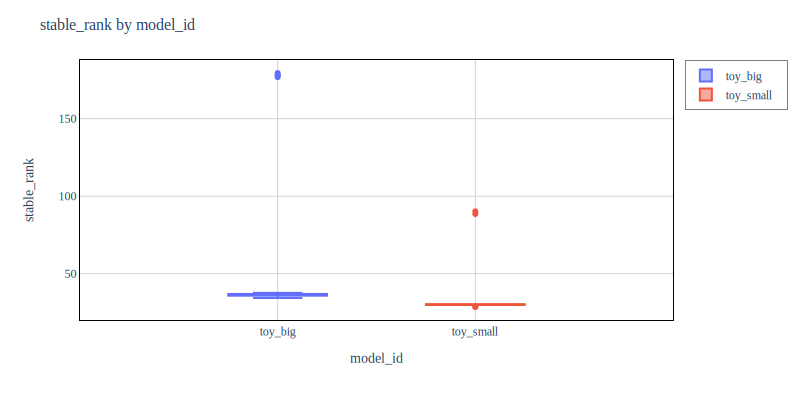

saved: examples/images/3k_theme_from_yaml.png


In [15]:
from diffract.viz.plots.scalar import BoxPlot
from diffract.viz.themes import DEFAULT_THEME, DARK_THEME, MINIMAL_THEME

# Plot with theme + coloring by metadata (layer_id)
with session:
    fig = session.draw(
        plot=BoxPlot(
            field="stable_rank",
            title="Stable Rank by Model (Theme + Color by layer_id)",
            group_by="model_id",
            color_by="layer_id",
            theme=DARK_THEME,
        )
    )
    show_and_save(fig, "3k_theme_color_by_layer")

# Same plot with minimal theme
with session:
    fig2 = session.draw(
        plot=BoxPlot(
            field="stable_rank",
            title="Stable Rank (Minimal Theme)",
            group_by="model_id",
            theme=MINIMAL_THEME,
        )
    )
    show_and_save(fig2, "3k_theme_minimal")

# Load theme from YAML file
with session:
    fig3 = session.draw(
        config_path=CONFIGS_DIR / "boxplot_stable_rank.yaml",
        theme_path=CONFIGS_DIR / "theme_example.yaml",
    )
    show_and_save(fig3, "3k_theme_from_yaml")

## 4. Get Results as Pandas DataFrame

In [16]:
with session:
    df = session.get_results("shape", "frob_norm", "effective_rank", "stable_rank", export_format="pandas").scalars
    print(f"Shape: {df.shape}")
    display(df.head())

Shape: (46, 14)


,parameter_uid,model_id,parameter_name,parameter_type,meta_in_model_idx,meta_torch_dtype,meta_layer_id,meta_head_id,meta_kind,meta_original_model_id,shape,frob_norm,effective_rank,stable_rank
0,6b468d1d,toy_big,layers.0.ffn,DENSE,20,torch.float32,0,NaN,ffn,7817f45a,"[1024, 512]",18.485630,474.430255,176.813677
1,2d7fc23a,toy_big,layers.0.heads.0.proj,DENSE,5,torch.float32,0,0.0,attn_proj,a7152d3f,"[64, 512]",4.615687,62.956388,34.273365
2,58d7eff9,toy_big,layers.0.heads.1.proj,DENSE,7,torch.float32,0,1.0,attn_proj,e6905a5f,"[64, 512]",4.622056,62.937088,37.165856
3,f126d216,toy_big,layers.0.heads.2.proj,DENSE,9,torch.float32,0,2.0,attn_proj,afb30ad4,"[64, 512]",4.603122,62.997859,36.323951
4,ab8d55a7,toy_big,layers.0.heads.3.proj,DENSE,11,torch.float32,0,3.0,attn_proj,614d2eb1,"[64, 512]",4.636604,62.989899,35.857855


## 5. List Models, Parameters, and Kernels

In [17]:
with session:
    print(f"Models: {session.list_models()}")
    print(f"Parameters: {len(session.list_parameters())}")
    print(f"Kernels: {session.list_kernels()[:10]}...")

Models: ['toy_big', 'toy_small']
Parameters: 46
Kernels: ['aspect_ratio', 'effective_rank', 'esd', 'esd_max', 'esd_min', 'esd_rand', 'esd_rand_max', 'esd_rand_min', 'expon_concentration', 'expon_p_value']...


## 6. Erase All Data

In [18]:
with session:
    print(f"Before: Models={session.list_models()}, Params={len(session.list_parameters())}")
    session.erase_results(erase_all=True)
    print(f"After: Models={session.list_models()}, Params={len(session.list_parameters())}")
    session.erase_models(erase_all=True)
    print(f"After: Models={session.list_models()}, Params={len(session.list_parameters())}")

Before: Models=['toy_big', 'toy_small'], Params=46
After: Models=['toy_big', 'toy_small'], Params=46
After: Models=[], Params=0


In [19]:
del session